In [4]:
import pandas as pd

df = pd.read_csv("data/fifa21_raw_data.csv")

df.head()

C:\Users\Noluthando\AppData\Local\Temp\ipykernel_13924\1508343990.py:3: DtypeWarning: Columns (0: Hits) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("data/fifa21_raw_data.csv")


,photoUrl,LongName,playerUrl,Nationality,Positions,Name,Age,↓OVA,POT,Team & Contract,...,A/W,D/W,IR,PAC,SHO,PAS,DRI,DEF,PHY,Hits
0,https://cdn.sofifa.com/players/158/023/21_60.png,Lionel Messi,http://sofifa.com/player/158023/lionel-messi/2...,Argentina,RW ST CF,L. Messi,33,93,93,\n\n\n\nFC Barcelona\n2004 ~ 2021\n\n,...,Medium,Low,5 ★,85,92,91,95,38,65,\n372
1,https://cdn.sofifa.com/players/020/801/21_60.png,C. Ronaldo dos Santos Aveiro,http://sofifa.com/player/20801/c-ronaldo-dos-s...,Portugal,ST LW,Cristiano Ronaldo,35,92,92,\n\n\n\nJuventus\n2018 ~ 2022\n\n,...,High,Low,5 ★,89,93,81,89,35,77,\n344
2,https://cdn.sofifa.com/players/200/389/21_60.png,Jan Oblak,http://sofifa.com/player/200389/jan-oblak/210005/,Slovenia,GK,J. Oblak,27,91,93,\n\n\n\nAtlético Madrid\n2014 ~ 2023\n\n,...,Medium,Medium,3 ★,87,92,78,90,52,90,\n86
3,https://cdn.sofifa.com/players/192/985/21_60.png,Kevin De Bruyne,http://sofifa.com/player/192985/kevin-de-bruyn...,Belgium,CAM CM,K. De Bruyne,29,91,91,\n\n\n\nManchester City\n2015 ~ 2023\n\n,...,High,High,4 ★,76,86,93,88,64,78,\n163
4,https://cdn.sofifa.com/players/190/871/21_60.png,Neymar da Silva Santos Jr.,http://sofifa.com/player/190871/neymar-da-silv...,Brazil,LW CAM,Neymar Jr,28,91,91,\n\n\n\nParis Saint-Germain\n2017 ~ 2022\n\n,...,High,Medium,5 ★,91,85,86,94,36,59,\n273


In [2]:
df.shape

(18979, 77)

In [3]:
df.columns

Index(['photoUrl', 'LongName', 'playerUrl', 'Nationality', 'Positions', 'Name',
       'Age', '↓OVA', 'POT', 'Team & Contract', 'ID', 'Height', 'Weight',
       'foot', 'BOV', 'BP', 'Growth', 'Joined', 'Loan Date End', 'Value',
       'Wage', 'Release Clause', 'Attacking', 'Crossing', 'Finishing',
       'Heading Accuracy', 'Short Passing', 'Volleys', 'Skill', 'Dribbling',
       'Curve', 'FK Accuracy', 'Long Passing', 'Ball Control', 'Movement',
       'Acceleration', 'Sprint Speed', 'Agility', 'Reactions', 'Balance',
       'Power', 'Shot Power', 'Jumping', 'Stamina', 'Strength', 'Long Shots',
       'Mentality', 'Aggression', 'Interceptions', 'Positioning', 'Vision',
       'Penalties', 'Composure', 'Defending', 'Marking', 'Standing Tackle',
       'Sliding Tackle', 'Goalkeeping', 'GK Diving', 'GK Handling',
       'GK Kicking', 'GK Positioning', 'GK Reflexes', 'Total Stats',
       'Base Stats', 'W/F', 'SM', 'A/W', 'D/W', 'IR', 'PAC', 'SHO', 'PAS',
       'DRI', 'DEF', 'PHY', 'Hits

In [10]:
df.rename(columns={"↓OVA": "Overall"}, inplace=True)

In [4]:
df.isnull().sum()

photoUrl       0
LongName       0
playerUrl      0
Nationality    0
Positions      0
              ..
PAS            0
DRI            0
DEF            0
PHY            0
Hits           0
Length: 77, dtype: int64

In [6]:
df.isnull().sum().sort_values(ascending=False)
#shows which columns are messy and where cleaning is needed

Loan Date End       17966
photoUrl                0
GK Diving               0
Sliding Tackle          0
Standing Tackle         0
                    ...  
Heading Accuracy        0
Finishing               0
Crossing                0
Attacking               0
Hits                    0
Length: 77, dtype: int64

In [7]:
df.info()
#tells which columns are numbers, string and where conversion is needed 

<class 'pandas.DataFrame'>
RangeIndex: 18979 entries, 0 to 18978
Data columns (total 77 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   photoUrl          18979 non-null  str   
 1   LongName          18979 non-null  str   
 2   playerUrl         18979 non-null  str   
 3   Nationality       18979 non-null  str   
 4   Positions         18979 non-null  str   
 5   Name              18979 non-null  str   
 6   Age               18979 non-null  int64 
 7   ↓OVA              18979 non-null  int64 
 8   POT               18979 non-null  int64 
 9   Team & Contract   18979 non-null  str   
 10  ID                18979 non-null  int64 
 11  Height            18979 non-null  str   
 12  Weight            18979 non-null  str   
 13  foot              18979 non-null  str   
 14  BOV               18979 non-null  int64 
 15  BP                18979 non-null  str   
 16  Growth            18979 non-null  int64 
 17  Joined            18979

In [8]:
df['Value'].head()
#shows messy text values

0    €67.5M
1      €46M
2      €75M
3      €87M
4      €90M
Name: Value, dtype: str

In [9]:
# Cleaning transformation
def convert_value(value):
    if isinstance(value, str):
        value = value.replace('€', '')
        if 'M' in value:
            return float(value.replace('M', '')) * 1_000_000
        elif 'K' in value:
            return float(value.replace('K', '')) * 1_000
        else:
            return float(value)
    return value

df['Value'] = df['Value'].apply(convert_value)

In [10]:
df['Value'].head()

0    67500000.0
1    46000000.0
2    75000000.0
3    87000000.0
4    90000000.0
Name: Value, dtype: float64

In [5]:
df['Wage'].head()
#checks what the wage column looks like

0    €560K
1    €220K
2    €125K
3    €370K
4    €270K
Name: Wage, dtype: str

In [ ]:
def convert_wage(wage):
    if isinstance(wage, str):
        wage = wage.replace('€', '')
        if 'K' in wage:
            return float(wage.replace('K', '')) * 1_000
        elif 'M' in wage:
            return float(wage.replace('M', '')) * 1_000_000
        else:
            return float(wage)
    return wage

df['Wage'] = df['Wage'].apply(convert_wage)

In [ ]:
df['Wage'].head()
#cleaned version

In [ ]:
df['Height'].head()
# checks data on the height column

In [ ]:
def convert_height(height):
    if isinstance(height, str):
        if "'" in height:
            feet, inches = height.split("'")
            inches = inches.replace('"', '')
            return (int(feet) * 30.48) + (int(inches) * 2.54)
    return height

df['Height'] = df['Height'].apply(convert_height)

In [ ]:
df['Height'].head()

In [ ]:
df['Weight'].head()
#checks content of column weight

In [ ]:
def convert_weight(weight):
    if isinstance(weight, str):
        weight = weight.replace('lbs', '')
        return float(weight) * 0.453592
    return weight

df['Weight'] = df['Weight'].apply(convert_weight)

In [ ]:
df['Weight'].head()

In [ ]:
df['Overall'].head()
# check the column overall and convert base rating and ptential boost into a single numeric value 

In [ ]:
def convert_overall(overall):
    if isinstance(overall, str):
        if '+' in overall:
            base, extra = overall.split('+')
            return int(base) + int(extra)
    return int(overall)

df['Overall'] = df['Overall'].apply(convert_overall)

In [ ]:
df['Overall'].head()

In [ ]:
df.isnull().sum().sort_values(ascending=False)
#checks for missing values, which columns are messy 

In [ ]:
threshold = len(df) * 0.5
df = df.dropna(axis=1, thresh=threshold)
# removes columns with more than 50% missing data

In [ ]:
#Fill small missing values
# for numeric columns:
df = df.fillna(df.median(numeric_only=True))
# for string columns:
df = df.fillna("Unknown")


In [2]:
df.isnull().sum().sort_values(ascending=False)
#shows fewer missing values 

NameError: name 'df' is not defined

In [6]:
df.head()

,photoUrl,LongName,playerUrl,Nationality,Positions,Name,Age,↓OVA,POT,Team & Contract,...,A/W,D/W,IR,PAC,SHO,PAS,DRI,DEF,PHY,Hits
0,https://cdn.sofifa.com/players/158/023/21_60.png,Lionel Messi,http://sofifa.com/player/158023/lionel-messi/2...,Argentina,RW ST CF,L. Messi,33,93,93,\n\n\n\nFC Barcelona\n2004 ~ 2021\n\n,...,Medium,Low,5 ★,85,92,91,95,38,65,\n372
1,https://cdn.sofifa.com/players/020/801/21_60.png,C. Ronaldo dos Santos Aveiro,http://sofifa.com/player/20801/c-ronaldo-dos-s...,Portugal,ST LW,Cristiano Ronaldo,35,92,92,\n\n\n\nJuventus\n2018 ~ 2022\n\n,...,High,Low,5 ★,89,93,81,89,35,77,\n344
2,https://cdn.sofifa.com/players/200/389/21_60.png,Jan Oblak,http://sofifa.com/player/200389/jan-oblak/210005/,Slovenia,GK,J. Oblak,27,91,93,\n\n\n\nAtlético Madrid\n2014 ~ 2023\n\n,...,Medium,Medium,3 ★,87,92,78,90,52,90,\n86
3,https://cdn.sofifa.com/players/192/985/21_60.png,Kevin De Bruyne,http://sofifa.com/player/192985/kevin-de-bruyn...,Belgium,CAM CM,K. De Bruyne,29,91,91,\n\n\n\nManchester City\n2015 ~ 2023\n\n,...,High,High,4 ★,76,86,93,88,64,78,\n163
4,https://cdn.sofifa.com/players/190/871/21_60.png,Neymar da Silva Santos Jr.,http://sofifa.com/player/190871/neymar-da-silv...,Brazil,LW CAM,Neymar Jr,28,91,91,\n\n\n\nParis Saint-Germain\n2017 ~ 2022\n\n,...,High,Medium,5 ★,91,85,86,94,36,59,\n273


In [ ]:
df.shape

In [ ]:
df.info()
# sanity check

In [ ]:
top_players = df.sort_values(by="Overall", ascending=False).head(10)
top_players[["Name", "Age", "Nationality", "Overall", "Value"]]
# shows best players, their nationality, their rating and their value

Matplotlib is building the font cache; this may take a moment.


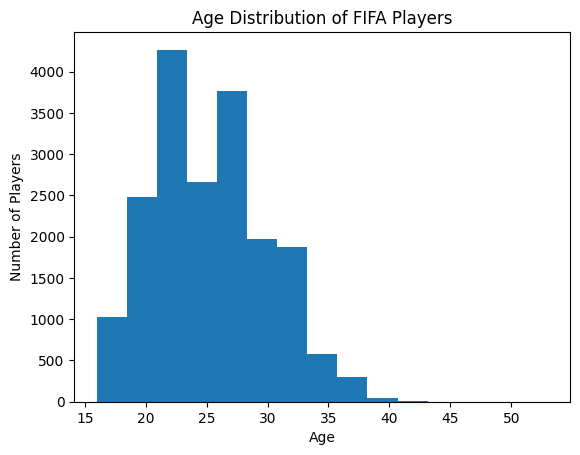

In [8]:
import matplotlib.pyplot as plt

plt.hist(df["Age"], bins=15)
plt.title("Age Distribution of FIFA Players")
plt.xlabel("Age")
plt.ylabel("Number of Players")
plt.show()


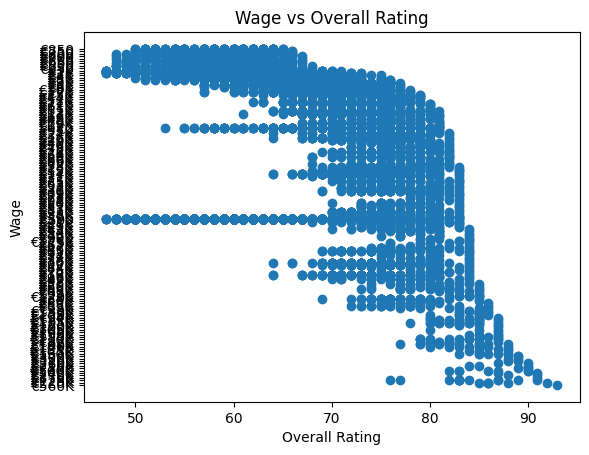

In [11]:
plt.scatter(df["Overall"], df["Wage"])
plt.title("Wage vs Overall Rating")
plt.xlabel("Overall Rating")
plt.ylabel("Wage")
plt.show()

# helps t confirm if better players earn more

In [ ]:
df["Nationality"].value_counts().head(10)
# top 10 nationality

Nationality
England        1704
Germany        1195
Spain          1065
France         1003
Argentina       943
Brazil          887
Japan           485
Netherlands     438
Italy           387
Sweden          380
Name: count, dtype: int64